# Cervical TLS workshop — figures

One notebook, grown one figure at a time. **Run the setup cell first**, then run
each figure cell on its own. Styling comes from `config/style.json`, the cell
vocabulary from `config/cell_types.json`, motif/TLS definitions from
`config/motifs.json`; vetted mechanics live in `src/workshop_lib.py`.

Labels come from Step 0 (`results/labels_miratyper.parquet`, the regenerated
alpha-0.1 calls). If that file isn't there, setup falls back to the baked obs
(alpha 1.0).

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd, networkx as nx, scanpy as sc
import matplotlib.pyplot as plt
sys.path.insert(0, "src")                  # workshop toolkit + config loader
import workshop_lib as wl
from config import STYLE, CELL_TYPES, MOTIFS, rgb

H5  = "data/cervical_tls_workshop/cervical_tls_crop.h5ad"
CB  = "data/cervical_tls_workshop/cell_boundaries.parquet"
ONT = "assets/cell_ontology_graph.pkl"

graph = wl.load_ontology(ONT)
ad = sc.read_h5ad(H5, backed="r")
cent = pd.DataFrame({"cell_id": ad.obs.index.astype(str),
                     "x_centroid": ad.obs["x_centroid"].to_numpy(float),
                     "y_centroid": ad.obs["y_centroid"].to_numpy(float)})

# Cell-type + malignancy labels: prefer Step-0 regenerated (alpha 0.1); else baked obs (alpha 1.0)
LBL = Path("results/labels_miratyper.parquet")
if LBL.exists():
    pr = pd.read_parquet(LBL)
    cid = pr["index"].apply(lambda b: b.decode() if isinstance(b, (bytes, bytearray)) else str(b))
    CT_COL = "cell_type_cdiam_miratyper_v1_constrained_alpha0010"   # alpha 0.1
    lab = pd.DataFrame({"cell_id": cid.values, "ct": pr[CT_COL].astype(str).values,
                        "p_malignant": pr["p_malignant"].astype(float).values})
    LABEL_SRC = f"Step-0 regenerated · {CT_COL} (alpha 0.1)"
else:
    o = ad.obs; CT_COL = "cell_type_cdiam_miratyper_v1_constrained_alpha0100"  # alpha 1.0
    lab = pd.DataFrame({"cell_id": o.index.astype(str), "ct": o[CT_COL].astype(str).values,
                        "p_malignant": o["p_malignant"].astype(float).values})
    LABEL_SRC = f"baked obs · {CT_COL} (alpha 1.0)"

df = lab.merge(cent, on="cell_id")                 # cell_id, ct, p_malignant, x/y_centroid
cb = wl.load_boundaries(CB)                        # cell_id, vertex_x, vertex_y (abs microns)
box = wl.box_from_boundaries(cb)                   # render box (x0,y0,x1,y1)
immune_set = wl.dset(graph, CELL_TYPES["immune_root"])
Path("figures").mkdir(exist_ok=True)
print(f"labels: {LABEL_SRC}")
print(f"{len(df):,} cells · immune {df.ct.isin(immune_set).sum():,} · "
      f"malignant(p>=0.5) {df.p_malignant.ge(0.5).sum():,}")

labels: Step-0 regenerated · cell_type_cdiam_miratyper_v1_constrained_alpha0010 (alpha 0.1)
26,047 cells · immune 6,512 · malignant(p>=0.5) 7,333


## Figure 1 — whole-crop malignancy + immune-ontology mask

Non-immune cells: red, saturation = `p_malignant` (white→red). Immune cells:
green→blue hue from 1-D MDS on cell-ontology distance. Legend embedded on the right.

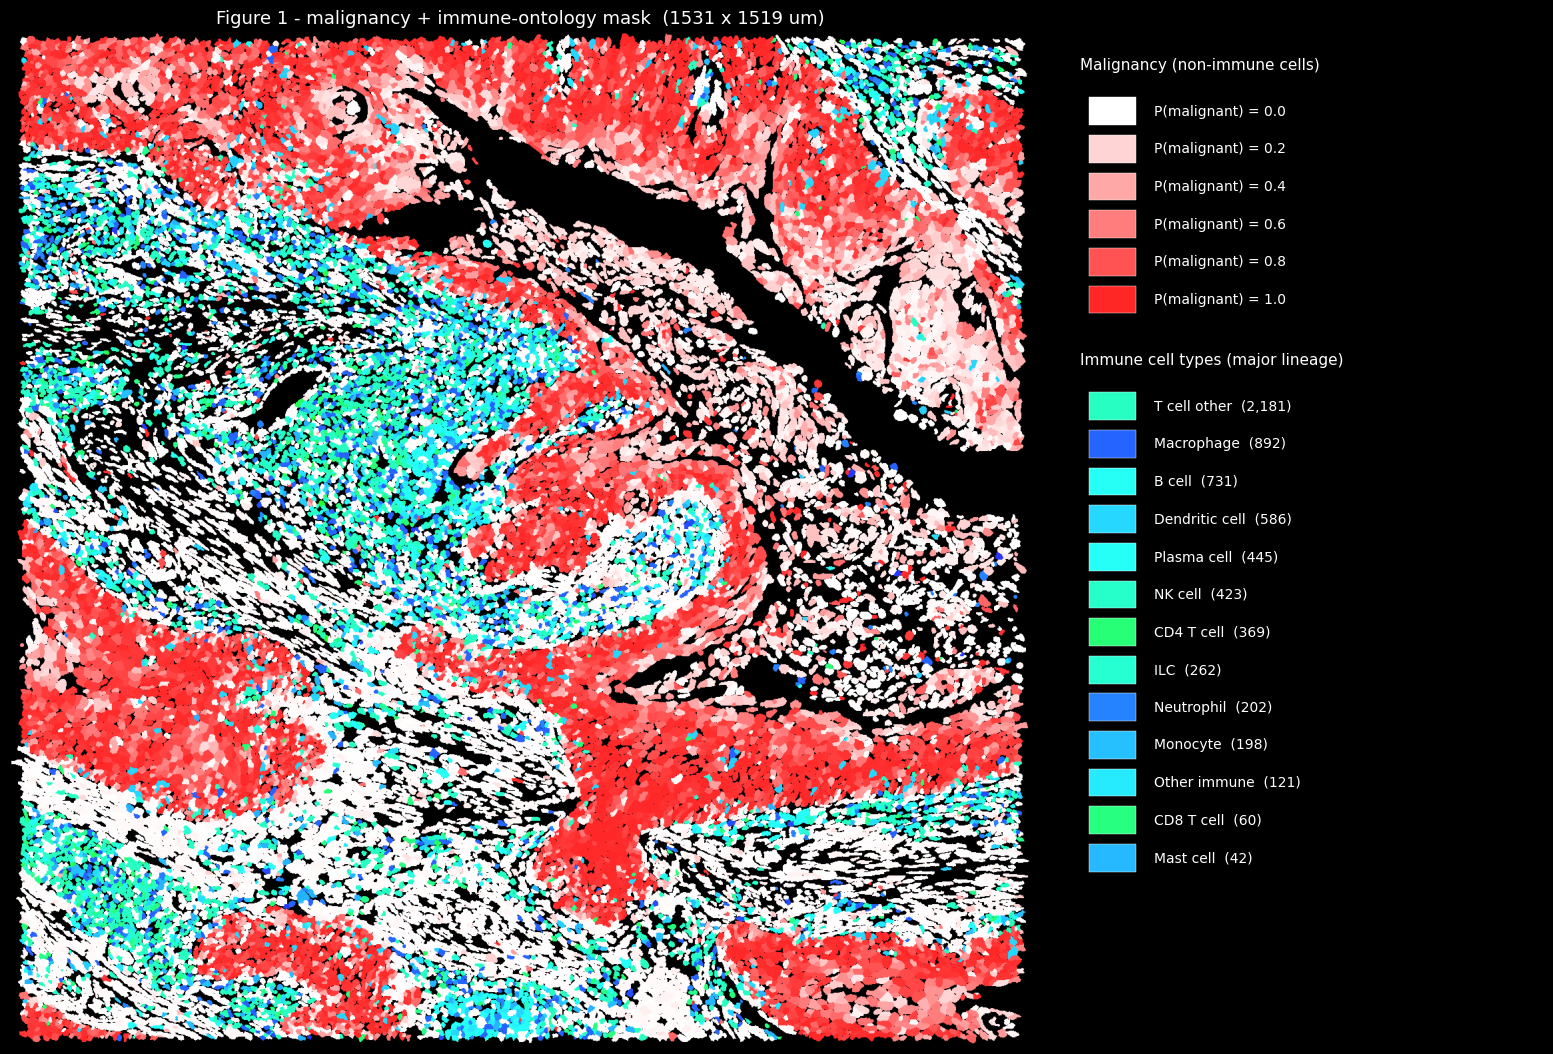

immune 6,512 (67 fine types -> 13 legend lineages) | CD8 in legend: [('CD8 T cell', 60)]


In [2]:
# --- colors: immune by ontology MDS ramp, non-immune by malignancy ramp ---
is_imm = df.ct.isin(immune_set)
imm = df[is_imm]
type_counts = imm.ct.value_counts()                      # descending
immune_colors = wl.immune_ontology_colors(list(type_counts.index), graph)
cell2color = {c: immune_colors[t] for c, t in zip(imm.cell_id, imm.ct)}
nonimm = df[~is_imm].dropna(subset=["p_malignant"])
for c, p in zip(nonimm.cell_id, nonimm.p_malignant):
    cell2color[c] = wl.malignant_color(p)

img = wl.render_polygons(cb, cell2color, box)            # 1 px/um, black bg, origin subtracted

# --- composite: mask (left) + legend (right) ---
fig = plt.figure(figsize=(16, 11), facecolor="black")
ax = fig.add_axes([0.02, 0.04, 0.66, 0.92]); ax.imshow(np.asarray(img))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Figure 1 - malignancy + immune-ontology mask  "
             f"({box[2]-box[0]:.0f} x {box[3]-box[1]:.0f} um)", color="white", fontsize=13)
lax = fig.add_axes([0.70, 0.05, 0.29, 0.90]); lax.set_facecolor("black")
lax.set_xlim(0, 1); lax.set_ylim(0, 1); lax.tick_params(length=0, labelleft=False, labelbottom=False)
y = 0.985
lax.text(0, y, "Malignancy (non-immune cells)", color="white", fontsize=11, va="top"); y -= 0.04
for i in range(6):
    p = i / 5
    lax.add_patch(plt.Rectangle((0.02, y-0.028), 0.10, 0.028,
                  facecolor=np.array(wl.malignant_color(p))/255, edgecolor="white", lw=0.3))
    lax.text(0.16, y-0.014, f"P(malignant) = {p:.1f}", color="white", fontsize=10, va="center"); y -= 0.038
y -= 0.03
lax.text(0, y, "Immune cell types (major lineage)", color="white", fontsize=11, va="top"); y -= 0.04
# legend rolled up to major lineages from config/cell_types.json (so sparse CD8 still shows)
for name, col, cnt in wl.immune_legend_rollup(imm.ct, immune_colors, graph):
    lax.add_patch(plt.Rectangle((0.02, y-0.028), 0.10, 0.028,
                  facecolor=np.array(col)/255, edgecolor="white", lw=0.3))
    lax.text(0.16, y-0.014, f"{name}  ({cnt:,})", color="white", fontsize=10, va="center"); y -= 0.038

fig.savefig("figures/fig1_malignancy_immune_mask.png", dpi=150, bbox_inches="tight", facecolor="black")
plt.show()
rollup = wl.immune_legend_rollup(imm.ct, immune_colors, graph)
print(f"immune {len(imm):,} ({type_counts.size} fine types -> {len(rollup)} legend lineages) "
      f"| CD8 in legend: {[ (n,c) for n,_,c in rollup if n=='CD8 T cell']}")


## Figure 2 — immune triads (CD8 + CD4 + dendritic cell)

Triad anchor = a CD8 T cell with at least one CD4 T cell **and** one dendritic cell within the triad radius (`config/motifs.json`). Cells filled with the categorical palette (`config/style.json`); magenta ring = triad, orange = tetrad (triad + macrophage). Triad concept from Espinosa-Carrasco et al., *Cancer Cell* 2024; the tetrad is our extension.

triad anchors in crop: 16  |  rings after thinning: 11  |  tetrads (+macrophage): 7


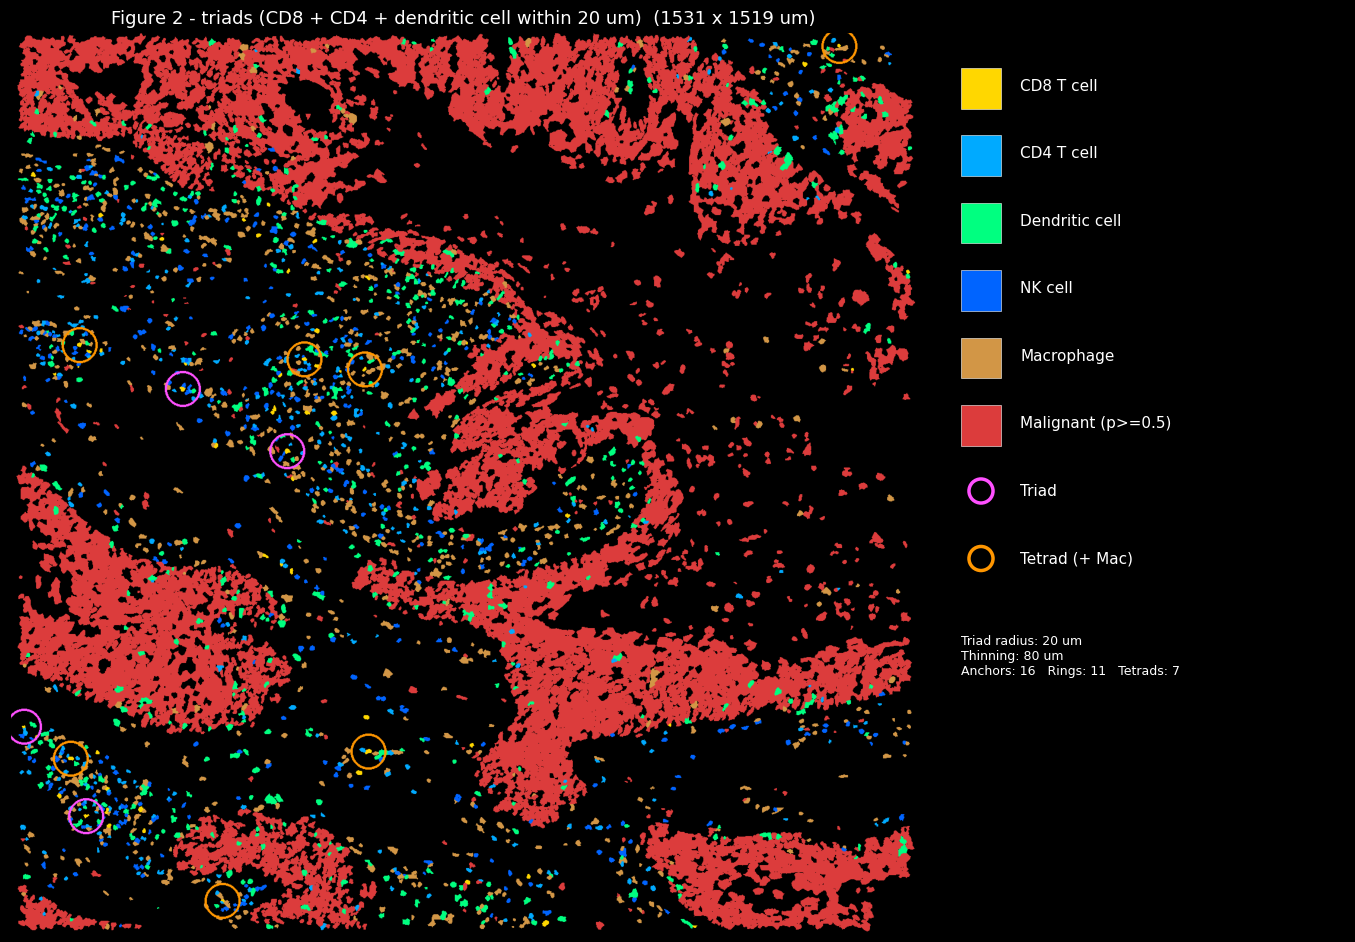

In [3]:
# --- triad anchors: a CD8 T cell with >=1 CD4 T cell AND >=1 dendritic cell within
#     the triad radius (config/motifs.json). Lineages resolved via config/cell_types.json. ---
anchors, has_mac = wl.find_triad_anchors(df, graph, ct_col="ct")   # has_mac flags tetrads (+macrophage)
keep = wl.greedy_thin(anchors, wl.THINNING_DIST_UM)                # display thinning (config/motifs.json)
circles, circ_mac = anchors[keep], has_mac[keep]
print(f"triad anchors in crop: {len(anchors)}  |  rings after thinning: {len(circles)}  "
      f"|  tetrads (+macrophage): {int(circ_mac.sum())}")

# --- categorical fills (config/style.json palette) + triad/tetrad rings ---
LINS = ["CD8 T cell", "CD4 T cell", "Dendritic cell", "NK cell", "Macrophage"]
cell2color = wl.categorical_colors(df, graph, LINS, ct_col="ct")   # + Malignant fills uncolored p>=0.5
img = wl.render_polygons(cb, cell2color, box)
wl.draw_circles(img, circles, circ_mac, box)                       # magenta=triad, orange=tetrad

fig = plt.figure(figsize=(14, 10), facecolor="black")
ax = fig.add_axes([0.03, 0.05, 0.66, 0.90], facecolor="black")
ax.imshow(np.asarray(img)); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Figure 2 - triads (CD8 + CD4 + dendritic cell within {wl.TRIAD_RADIUS_UM:.0f} um)  "
             f"({box[2]-box[0]:.0f} x {box[3]-box[1]:.0f} um)", color="white", fontsize=13)

lax = fig.add_axes([0.71, 0.05, 0.28, 0.90]); lax.set_facecolor("black")
lax.set_xlim(0, 1); lax.set_ylim(0, 1); lax.tick_params(length=0, labelleft=False, labelbottom=False)
items = [(n, wl.rgb(n), "p") for n in LINS] + [
    ("Malignant (p>=0.5)", wl.rgb("Malignant"), "p"),
    ("Triad", wl.COLOR_TRIAD, "c"), ("Tetrad (+ Mac)", wl.COLOR_TETRA, "c")]
y = 0.95
for name, col, kind in items:
    if kind == "c":
        lax.scatter([0.07], [y-0.01], s=300, facecolors="none", edgecolors=np.array(col)/255, linewidths=2.5)
    else:
        lax.add_patch(plt.Rectangle((0.02, y-0.035), 0.10, 0.045, facecolor=np.array(col)/255, edgecolor="white", lw=0.4))
    lax.text(0.17, y-0.01, name, fontsize=11, va="center", color="white"); y -= 0.075
lax.text(0.02, y-0.02,
         f"Triad radius: {wl.TRIAD_RADIUS_UM:.0f} um\nThinning: {wl.THINNING_DIST_UM:.0f} um\n"
         f"Anchors: {len(anchors)}   Rings: {len(circles)}   Tetrads: {int(circ_mac.sum())}",
         fontsize=9, color="white", va="top")

fig.savefig("figures/fig2_triad_zoom.png", dpi=150, bbox_inches="tight", facecolor="black")
plt.show()


## Figure 3 — anatomy of one tertiary lymphoid structure

Search the crop for the 100 µm core with the highest **TLS-score** (`config/motifs.json` → `tls_score`), report its germinal-centre counts, then render a 700 µm window around it with the categorical palette — B cells pink, plasma magenta — plus the triad/tetrad rings from Figure 2.

highest-TLS-score core centroid: (4319.9, 3700.4) um   TLS-score = 125.4
  core(100um): B=52  plasma=14  T=258  DC=20  CXCL13+=106  CCL19/21+=130  LAMP3+DC=3


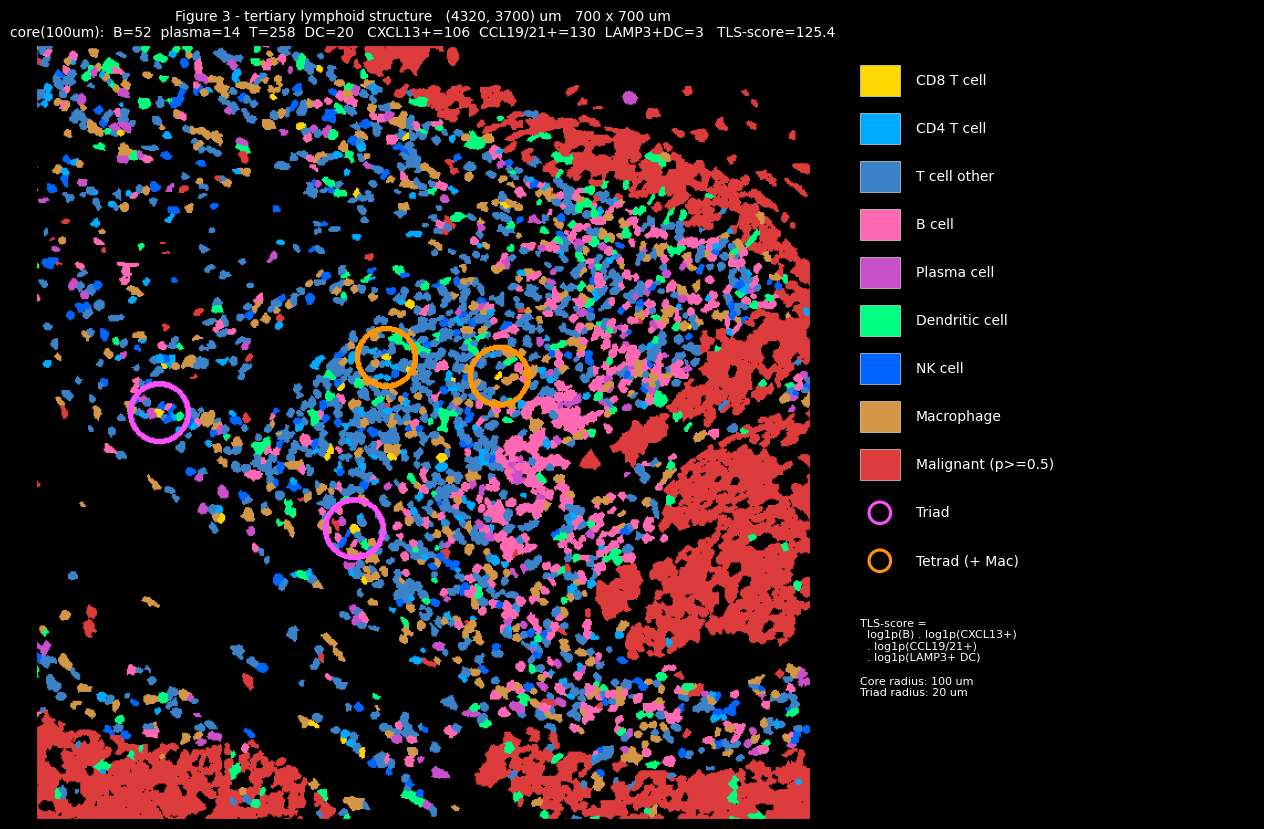

In [4]:
from scipy.spatial import cKDTree

# --- TLS scoring setup (config/motifs.json -> tls_score) ---
TLS = wl.MOTIFS["tls_score"]; CORE = TLS["core_radius_um"]; mk = TLS["markers"]
H5 = "data/cervical_tls_workshop/cervical_tls_crop.h5ad"

# lineage + marker-positive masks over all crop cells (aligned to df row order)
B  = df.ct.isin(wl.lineage_set(graph, "B cell")).to_numpy()
PL = df.ct.isin(wl.lineage_set(graph, "Plasma cell")).to_numpy()
Tc = df.ct.isin(wl.lineage_set(graph, "T cell other") |
                wl.lineage_set(graph, "CD8 T cell") |
                wl.lineage_set(graph, "CD4 T cell")).to_numpy()
DC = df.ct.isin(wl.lineage_set(graph, "Dendritic cell")).to_numpy()
ids = df.cell_id.tolist()
cxcl13 = wl.gene_positive_mask(H5, ids, mk["follicular_b_chemokine"])
ccl = np.zeros(len(df), bool)
for gname in mk["t_zone_chemokines"]:
    ccl |= wl.gene_positive_mask(H5, ids, gname)
lamp3 = wl.gene_positive_mask(H5, ids, mk["mature_migratory_dc"])

xy = df[["x_centroid", "y_centroid"]].to_numpy()
tree = cKDTree(xy)

def core_stats(cx, cy):
    idx = np.array(tree.query_ball_point([cx, cy], CORE), int)
    nB, nPL, nT, nDC = int(B[idx].sum()), int(PL[idx].sum()), int(Tc[idx].sum()), int(DC[idx].sum())
    n13, nccl, nl3 = int(cxcl13[idx].sum()), int(ccl[idx].sum()), int((lamp3[idx] & DC[idx]).sum())
    score = float(np.log1p(nB) * np.log1p(n13) * np.log1p(nccl) * np.log1p(nl3))
    return dict(n_B=nB, n_plasma=nPL, n_T=nT, n_DC=nDC, n_CXCL13=n13,
                n_CCL19_21=nccl, n_LAMP3_DC=nl3, score=score)

# --- find the 100um core with the highest TLS score (grid over interior so the 700um window fits) ---
WIN = 700.0; half = WIN / 2
x0, y0, x1, y1 = box
best = None
for cx in np.arange(x0 + half, x1 - half, 15.0):
    for cy in np.arange(y0 + half, y1 - half, 15.0):
        s = core_stats(cx, cy)
        if best is None or s["score"] > best[2]["score"]:
            best = (float(cx), float(cy), s)
CX, CY, st = best
print(f"highest-TLS-score core centroid: ({CX:.1f}, {CY:.1f}) um   TLS-score = {st['score']:.1f}")
print(f"  core(100um): B={st['n_B']}  plasma={st['n_plasma']}  T={st['n_T']}  DC={st['n_DC']}  "
      f"CXCL13+={st['n_CXCL13']}  CCL19/21+={st['n_CCL19_21']}  LAMP3+DC={st['n_LAMP3_DC']}")

# --- triad/tetrad rings (computed over the whole crop) ---
anchors, has_mac = wl.find_triad_anchors(df, graph, ct_col="ct")
keep = wl.greedy_thin(anchors, wl.THINNING_DIST_UM); circles, circ_mac = anchors[keep], has_mac[keep]

# --- render the 700um window, categorical palette incl. B (pink) + plasma (magenta) ---
LINS = ["CD8 T cell", "CD4 T cell", "T cell other", "B cell", "Plasma cell",
        "Dendritic cell", "NK cell", "Macrophage"]
cell2color = wl.categorical_colors(df, graph, LINS, ct_col="ct")
wbox = (CX - half, CY - half, CX + half, CY + half)
img = wl.render_polygons(cb, cell2color, wbox)
wl.draw_circles(img, circles, circ_mac, wbox, radius_um=28.0, width_px=5)

fig = plt.figure(figsize=(13, 9), facecolor="black")
ax = fig.add_axes([0.03, 0.05, 0.62, 0.86], facecolor="black"); ax.imshow(np.asarray(img))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Figure 3 - tertiary lymphoid structure   ({CX:.0f}, {CY:.0f}) um   {WIN:.0f} x {WIN:.0f} um\n"
             f"core(100um):  B={st['n_B']}  plasma={st['n_plasma']}  T={st['n_T']}  DC={st['n_DC']}   "
             f"CXCL13+={st['n_CXCL13']}  CCL19/21+={st['n_CCL19_21']}  LAMP3+DC={st['n_LAMP3_DC']}   "
             f"TLS-score={st['score']:.1f}", color="white", fontsize=10)

lax = fig.add_axes([0.67, 0.06, 0.31, 0.86]); lax.set_facecolor("black")
lax.set_xlim(0, 1); lax.set_ylim(0, 1); lax.tick_params(length=0, labelleft=False, labelbottom=False)
items = [(n, wl.rgb(n), "p") for n in LINS] + [
    ("Malignant (p>=0.5)", wl.rgb("Malignant"), "p"),
    ("Triad", wl.COLOR_TRIAD, "c"), ("Tetrad (+ Mac)", wl.COLOR_TETRA, "c")]
y = 0.95
for name, col, kind in items:
    if kind == "c":
        lax.scatter([0.07], [y-0.008], s=240, facecolors="none", edgecolors=np.array(col)/255, linewidths=2.2)
    else:
        lax.add_patch(plt.Rectangle((0.02, y-0.028), 0.10, 0.04, facecolor=np.array(col)/255, edgecolor="white", lw=0.4))
    lax.text(0.16, y-0.008, name, fontsize=10, va="center", color="white"); y -= 0.062
lax.text(0.02, y-0.02,
         "TLS-score =\n  log1p(B) . log1p(CXCL13+)\n  . log1p(CCL19/21+)\n  . log1p(LAMP3+ DC)\n\n"
         f"Core radius: {CORE:.0f} um\nTriad radius: {wl.TRIAD_RADIUS_UM:.0f} um",
         fontsize=8, color="white", va="top")
fig.savefig("figures/fig3_single_tls.png", dpi=150, bbox_inches="tight", facecolor="black")
plt.show()
